In [1]:

import torch
import torchvision
print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("CUDA is available:", torch.cuda.is_available())
import sys
!{sys.executable} -m pip install opencv-python matplotlib scikit-learn

PyTorch version: 2.9.0+cu128
Torchvision version: 0.24.0+cu128
CUDA is available: True


In [2]:
# once per runtime
!git clone -b feat/agent_tools https://github.com/flowithin/sam3.git
%cd sam3
!git pull
!pip install -e .

Cloning into 'sam3'...
remote: Enumerating objects: 1096, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 1096 (delta 76), reused 44 (delta 42), pack-reused 1011 (from 2)
Receiving objects: 100% (1096/1096), 59.48 MiB | 43.60 MiB/s, done.
Resolving deltas: 100% (327/327), done.
/content/sam3
Already up to date.
Obtaining file:///content/sam3
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 127.9 MB/s eta 0:00:00
  Building editable fo

### login to Huggingface

In [1]:
# Add huggingface token to the notebook secret keys
from google.colab import userdata
from huggingface_hub import login

# Get the token from Colab secrets
HF_TOKEN = userdata.get('HF_TOKEN')

# Log in to Hugging Face
if HF_TOKEN:
    login(HF_TOKEN)
    print("Successfully logged in to Hugging Face!")
else:
    print("HF_TOKEN secret not found or notebook access not enabled.")

Successfully logged in to Hugging Face!


In [2]:
from sam3.agent.agent_video_tracker import Sam3TrackingTool, DetectedObject, ObjectList

/usr/local/lib/python3.12/dist-packages/torch/backends/__init__.py:46: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  self.setter(val)


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
video_path = "/content/drive/MyDrive/Thomas pipelines/video assets/golden-state-warriors-minnesota-timberwolves-game-1-q1-05.32-05.25.mp4"
# !mkdir /content/annotated_basket

In [5]:
sam3_tracker_players = Sam3TrackingTool(
    video_path=video_path,
    bpe_path="/content/sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"
)

INFO 2026-02-13 14:13:05,858 1072 sam3_video_predictor.py: 300: using the following GPU IDs: [0]
INFO 2026-02-13 14:13:06,139 1072 sam3_video_predictor.py: 316: 


	*** START loading model on all ranks ***


INFO 2026-02-13 14:13:06,139 1072 sam3_video_predictor.py: 318: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-02-13 14:13:15,760 1072 sam3_video_base.py: 125: setting max_num_objects=10000 and num_obj_for_compile=16


config.json:   0%|          | 0.00/25.8k [00:00<?, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

INFO 2026-02-13 14:13:28,246 1072 sam3_video_predictor.py: 320: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-02-13 14:13:28,247 1072 sam3_video_predictor.py: 331: 


	*** DONE loading model on all ranks ***


frame loading (OpenCV) [rank=0]: 100%|██████████| 222/222 [00:01<00:00, 215.76it/s]


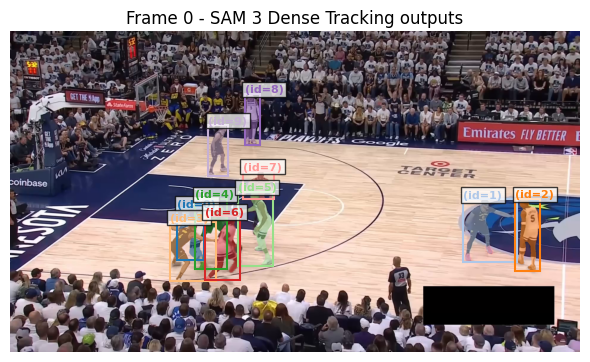

In [6]:
out = sam3_tracker_players._add_prompt(prompt_text_str="on court players")

propagate_in_video:   0%|          | 0/222 [00:00<?, ?it/s]

propagate_in_video: 0it [00:00, ?it/s]

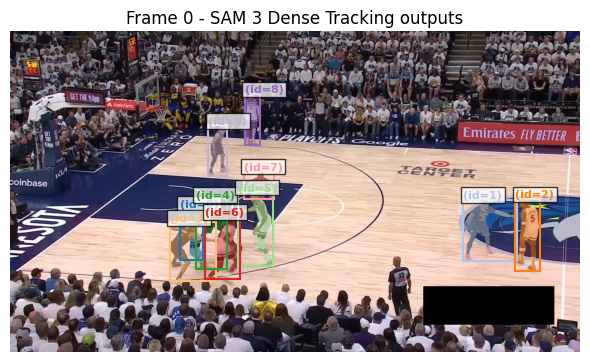

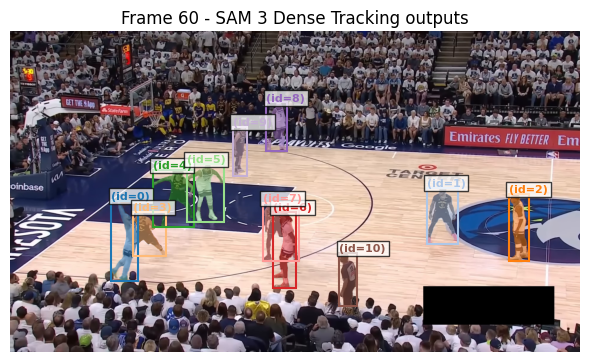

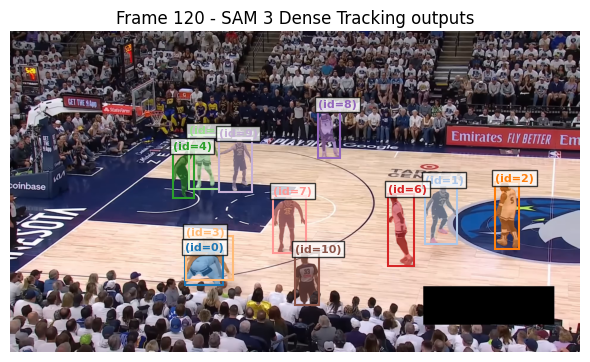

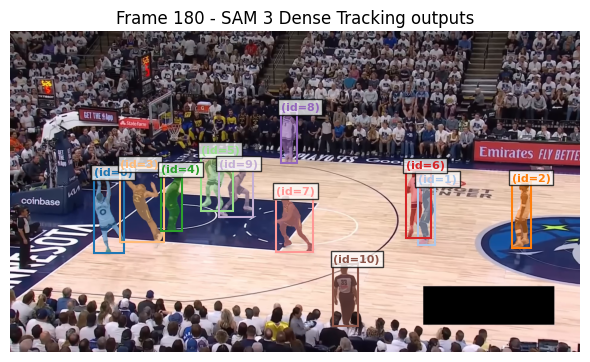

In [7]:
sam3_tracker_players._propagate()

In [13]:
sam3_tracker_players._get_object_list().from_outputs_per_frame(sam3_tracker_players.outputs_per_frame)

### To save the checkpoints

In [21]:
import os
os.makedirs("/content/checkpoints", exist_ok=True)
sam3_tracker_players._save_objects(path="/content/checkpoints")

In [ ]:
#now you can tarball it to pass it around
!tar -czf checkpoints.tar.gz /content/checkpoints/
#to untar
!tar -xzf checkpoints.tar.gz

### To load the checkpoints

In [22]:
#to load object from checkpoints:
players = ObjectList()
for i in range(10):
  players.add_object(DetectedObject.load("/content/checkpoints/", id=i))
print(players)

ObjectList:
  - id=0, label=, tracked: True
  - id=1, label=, tracked: True
  - id=2, label=, tracked: True
  - id=3, label=, tracked: True
  - id=4, label=, tracked: True
  - id=5, label=, tracked: True
  - id=6, label=, tracked: True
  - id=7, label=, tracked: True
  - id=8, label=, tracked: True
  - id=9, label=, tracked: True


now players is a class wrapping around list of Objects.

In [25]:
#the mask
players.get_objects()[0].masks

{0: array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 1: array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False]]),
 2: array([[False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., False, False, False],
        ...,
        [False, False, False, ..., False, False, False],
        [False, False, False, ..., F

In [27]:
#the bounding boxes
players.get_objects()[0].bounding_boxes

{0: [0.29739582538604736,
  0.5518518686294556,
  0.3385416567325592,
  0.7138888835906982],
 1: [0.2822916805744171,
  0.5537037253379822,
  0.3333333432674408,
  0.7148148417472839],
 2: [0.2723958194255829,
  0.5546296238899231,
  0.3322916626930237,
  0.7157407402992249],
 3: [0.2692708373069763,
  0.5592592358589172,
  0.3296875059604645,
  0.7120370268821716],
 4: [0.2666666805744171,
  0.5564814805984497,
  0.32760417461395264,
  0.7120370268821716],
 5: [0.26354166865348816,
  0.5564814805984497,
  0.32604166865348816,
  0.710185170173645],
 6: [0.2614583373069763,
  0.5592592358589172,
  0.3244791626930237,
  0.710185170173645],
 7: [0.2578125, 0.5629629492759705, 0.328125, 0.7185184955596924],
 8: [0.25468748807907104,
  0.5638889074325562,
  0.32864582538604736,
  0.720370352268219],
 9: [0.2515625059604645,
  0.5657407641410828,
  0.32604166865348816,
  0.720370352268219],
 10: [0.24895833432674408,
  0.5657407641410828,
  0.2901041805744171,
  0.7166666388511658],
 11: [0.

### You can directly use some position decoding functions provided

In [30]:
# the player with id=1 is defending player with id=2
obj1 = players.get_objects()[1]
obj2 = players.get_objects()[2]
obj1.near(frame_idx=0, object=obj1, radius=0.2)

True